# Heart Diasease

## Modelo preditivo usando Cat Boost para Classificar pessoas com alto risco de doenças cardiacas.

### Informações do Conjunto de Dados

1 - age: idade do paciente
2-

Importações das Bibliotecas Ultilizadas no Projeto

In [ ]:
# Instalação do CatBoost (Descomente a linha abaixo se for a primeira vez rodando no Colab)
!pip install catboost

# Manipulação de Dados e Matemática Básica
import pandas as pd
import numpy as np

# Visualização Gráfica (Matriz de Confusão e Curva ROC)
import matplotlib.pyplot as plt
import seaborn as sns

# Separação de Dados e Validação Cruzada
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Métricas de Avaliação (Foco nos erros e no Recall)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import recall_score, accuracy_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve

# Modelos de Benchmark (Para provar que o CatBoost vence os clássicos)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo de Classificacao
from catboost import CatBoostClassifier

###Carregando dados do arquivo CSV

In [4]:
# Hospedado no repositório do projeto
url = 'https://raw.githubusercontent.com/GabrielSenkovski/Heart_Diasease_Prediction/refs/heads/main/Heart_Disease_Prediction.csv'
df_heart = pd.read_csv(url)
# Verificando as 5 primeiras linhas
df_heart.head()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
# Verificando Dimenssões do arquivo.
df_heart.shape

# Verificando informações do arquivo
df_heart.info()

# Verificando se há valores nulos
df_heart.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


#Fluxo de Trabalho em Etapas

##Etapa 1: Separação de Alvo e Atributos (X e y)

###X = Conjunto de Variavies independentes do conjunto

###y = Variável objetivo (target: "Presence", "Absence")





![Ranking de Variáveis ordenada pelo ReliefF](https://raw.githubusercontent.com/GabrielSenkovski/Heart_Diasease_Prediction/a37900438cade16cf0b0006a48a0ff5a76f8b8e7/imagens/Rank_Featuares_Orange.png)

###Ranking de Variáveis X ordenada pelo ReliefF

Essa imagem acima Demonstra o conjunto Total de 13 Variáveis elegíveis para o conjunto X.

A ferramenta [Orange Data Mining](https://orangedatamining.com/) foi ultilizada para gerar um rank que analisa a correlação entre as featuares, visando manter apenas as variaveis com maior impacto para o modelo.

Embora o CatBoost possua métodos para escolher as melhores variáveis de forma autônoma, a exclusão manual dessas cinco variáveis foi fundamentada no ranqueamento de irrelevância do algoritmo ReliefF, olhando também para outras métricas em segundo plano, conforme demonstrado na imagem.

  Essa limpeza prévia elimina ruídos estatísticos e reduz o risco de overfitting em um conjunto restrito de dados (com apenas 270 amostras).

  O ReliefF é altamente recomendado para dados de saúde, pois avalia a utilidade de um atributo considerando sua interação com outras variáveis no contexto de instâncias vizinhas.

As 5 Variáveis excluidas foram os 5 elementos da cauda do rank:


*  Cholesterol
*  FBS over 120
*  BP
*  Age
*  Max HR


  Por Fim, as 8 Váriaveis restantes representam o Conjunto X.  


In [20]:
# Remoção das 5 variáveis (Feature Selection guiada pelo ReliefF)
colunas_para_remover = ['Cholesterol', 'FBS over 120', 'BP', 'Age', 'Max HR']
df_limpo = df_heart.drop(columns=colunas_para_remover)

# Separando as variáveis independentes de y
X = df_limpo.drop(columns=['Heart Disease'])

# Separando a variável dependente (y - O diagnóstico real)
y = df_limpo['Heart Disease']

# Verificando as separações
print("Formato do X (Variáveis):", X.shape)
print("Formato do y (Target):", y.shape)

Formato do X (Variáveis): (270, 8)
Formato do y (Target): (270,)


##Etapa 2: Divisão de Treino e Teste

O conjunto de dados será particionado em 80% para o treinamento do modelo e 20% para testes de validação isolados. Esse processo utilizará a divisão estratificada para assegurar matematicamente que a proporção original das classes (45% doentes e 55% saudáveis) seja rigorosamente mantida em ambas as amostras. Confore a Celula Abaixo mostra a proporção desbalanceada por 10 pontos percentuais de vantagem para a classe "Absence".

In [21]:
# Calcula a porcentagem de cada classe dentro de y
proporcoes = y.value_counts(normalize=True) * 100

print("Proporção das classes no dataset:")
print(proporcoes)

Proporção das classes no dataset:
Heart Disease
Absence     55.555556
Presence    44.444444
Name: proportion, dtype: float64


In [22]:
# Executando a Divisão Estratificada (80% Treino / 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,   # Separa 20% para o "Exame Final"
    stratify=y,       # Garante que a proporção 45/55 se mantenha em ambos
    random_state=42   # Garante que o sorteio seja sempre o mesmo (reprodutibilidade)
)

# Checagem para confirmar os tamanhos
print("Pacientes para o modelo estudar (X_train):", X_train.shape)
print("Pacientes para o modelo testar (X_test):", X_test.shape)

Pacientes para o modelo estudar (X_train): (216, 8)
Pacientes para o modelo testar (X_test): (54, 8)


aaa

In [23]:
# ==========================================
# ETAPA 3: CONFIGURAÇÃO E TREINAMENTO CATBOOST
# ==========================================

# 1. O "Manual de Instruções" (Aviso de Categorias)
# Identificamos as 6 colunas que são rótulos médicos disfarçados de números
variaveis_categoricas = [
    'Sex',
    'Chest pain type',
    'Exercise angina',
    'Slope of ST',
    'Thallium',
    'EKG results'
]

# 2. Instanciando o Cérebro do Modelo (O Botão de Pânico)
# O parâmetro auto_class_weights='Balanced' avisa que errar o diagnóstico de um doente custa caro
modelo_cat = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_state=42,
    verbose=False  # Mantém a tela limpa, escondendo o log gigante de processamento
)

# 3. O Treinamento (O Encaixe Perfeito)
# Passamos os dados de estudo (X_train), o gabarito (y_train) e anexamos a lista de categorias
modelo_cat.fit(X_train, y_train, cat_features=variaveis_categoricas)

print("Etapa 3 Concluída: Modelo CatBoost treinado e balanceado com sucesso!")

Etapa 3 Concluída: Modelo CatBoost treinado e balanceado com sucesso!


--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

     Absence       0.89      0.83      0.86        30
    Presence       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



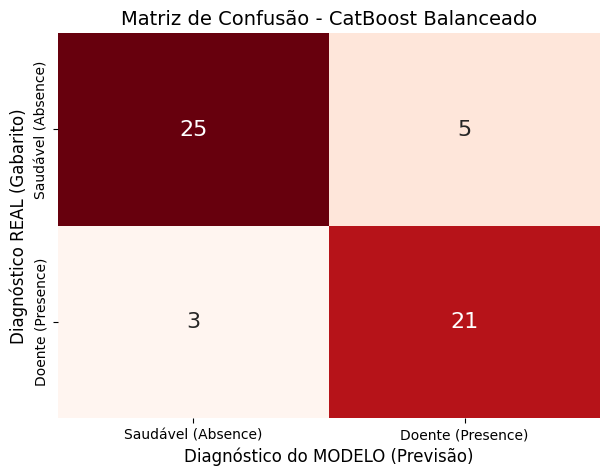

In [24]:
# ==========================================
# ETAPA 4: O BOLETIM MÉDICO (Métricas e Matriz)
# ==========================================

# 1. Aplicando o "Exame Final"
# O modelo olha para os sintomas (X_test) e tenta adivinhar o diagnóstico
y_pred = modelo_cat.predict(X_test)

# 2. O Relatório Clínico (Foco no Recall)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))

# 3. Gerando a Matriz de Confusão Visual (O Raio-X dos Erros)
cm = confusion_matrix(y_test, y_pred)

# Configurando o gráfico para ficar visualmente profissional
plt.figure(figsize=(7, 5))
# Nota: Como as classes são textos, o Scikit-Learn as ordena alfabeticamente: 0 = Absence, 1 = Presence
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Saudável (Absence)', 'Doente (Presence)'],
            yticklabels=['Saudável (Absence)', 'Doente (Presence)'],
            cbar=False, annot_kws={"size": 16})

plt.title('Matriz de Confusão - CatBoost Balanceado', fontsize=14)
plt.ylabel('Diagnóstico REAL (Gabarito)', fontsize=12)
plt.xlabel('Diagnóstico do MODELO (Previsão)', fontsize=12)
plt.show()